# TP Analyse de Données — Olist E-Commerce
**Université Kofi Annan de Guinée — L3 MIAGE  — 2025-2026**

**Nom :** CAMARA
**Prénom :** SARAN  
**Formateur :** Almamy Camara  



---
## Partie 1 — Chargement & Exploration des Données 

### 1.1 — Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# Adapter ce chemin selon votre environnement
# Sur Google Colab, montez votre Drive ou utilisez : BASE = '/content/drive/MyDrive/olist_analysis/data/raw/'
BASE = 'C:/Users/HP/Desktop/olist_analysis/data/raw/'

orders     = pd.read_csv(BASE + 'olist_orders_dataset.csv')
items      = pd.read_csv(BASE + 'olist_order_items_dataset.csv')
products   = pd.read_csv(BASE + 'olist_products_dataset.csv')
customers  = pd.read_csv(BASE + 'olist_customers_dataset.csv')
reviews    = pd.read_csv(BASE + 'olist_order_reviews_dataset.csv')
sellers    = pd.read_csv(BASE + 'olist_sellers_dataset.csv')
payments   = pd.read_csv(BASE + 'olist_order_payments_dataset.csv')
categories = pd.read_csv(BASE + 'product_category_name_translation.csv')

print('Chargement terminé !')

Chargement terminé !


### Question 1  — Aperçu et dimensions des DataFrames

In [2]:
# Affichage des 5 premières lignes et dimensions de chaque DataFrame
dataframes = {
    'orders': orders,
    'items': items,
    'products': products,
    'customers': customers,
    'reviews': reviews,
    'sellers': sellers,
    'payments': payments,
    'categories': categories
}

for name, df in dataframes.items():
    print(f'\n=== {name.upper()} — {df.shape[0]} lignes x {df.shape[1]} colonnes ===')
    display(df.head())


=== ORDERS — 99441 lignes x 8 colonnes ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



=== ITEMS — 112650 lignes x 7 colonnes ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



=== PRODUCTS — 32951 lignes x 9 colonnes ===


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



=== PAYMENTS — 103886 lignes x 5 colonnes ===


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



=== CATEGORIES — 71 lignes x 2 colonnes ===


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [3]:
# Tableau récapitulatif des dimensions
dim_data = [
    ['orders',     orders.shape[0],     orders.shape[1],     'order_id'],
    ['items',      items.shape[0],      items.shape[1],      'order_id + product_id'],
    ['products',   products.shape[0],   products.shape[1],   'product_id'],
    ['customers',  customers.shape[0],  customers.shape[1],  'customer_id'],
    ['reviews',    reviews.shape[0],    reviews.shape[1],    'order_id'],
    ['sellers',    sellers.shape[0],    sellers.shape[1],    'seller_id'],
    ['payments',   payments.shape[0],   payments.shape[1],   'order_id'],
    ['categories', categories.shape[0], categories.shape[1], 'product_category_name'],
]

dim_df = pd.DataFrame(dim_data, columns=['DataFrame', 'Lignes', 'Colonnes', 'Clé principale'])
display(dim_df)

,DataFrame,Lignes,Colonnes,Clé principale
0,orders,99441,8,order_id
1,items,112650,7,order_id + product_id
2,products,32951,9,product_id
3,customers,99441,5,customer_id
4,reviews,99224,7,order_id
5,sellers,3095,4,seller_id
6,payments,103886,5,order_id
7,categories,71,2,product_category_name


### Question 2  — Types des colonnes de dates dans `orders`

In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Réponse Q2 :**  
Après exécution de `.info()`, les colonnes de dates (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_customer_date`, `order_estimated_delivery_date`) sont de type **`object`** (chaîne de caractères), et non de type `datetime64`. Ce n'est **pas correct** : pour effectuer des calculs de différences temporelles (délais de livraison, retards), il est indispensable de les convertir en `datetime64` avec `pd.to_datetime()`. Sans cette conversion, les opérations arithmétiques sur les dates seront impossibles.

### 1.2 — Valeurs manquantes

In [5]:
def missing_report(df, name):
    pct = round(df.isna().sum() / len(df) * 100, 2)
    pct = pct[pct > 0].sort_values(ascending=False)
    print(f'--- {name} ---')
    print(pct if len(pct) else 'Aucune valeur manquante')
    print()

for name, df in dataframes.items():
    missing_report(df, name)

--- orders ---
order_delivered_customer_date    2.98
order_delivered_carrier_date     1.79
order_approved_at                0.16
dtype: float64

--- items ---
Aucune valeur manquante

--- products ---
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

--- customers ---
Aucune valeur manquante

--- reviews ---
review_comment_title      88.34
review_comment_message    58.70
dtype: float64

--- sellers ---
Aucune valeur manquante

--- payments ---
Aucune valeur manquante

--- categories ---
Aucune valeur manquante



### Question 3 — Valeurs manquantes : analyse métier

**Réponse Q3 :**  
Les colonnes présentant le plus de valeurs manquantes sont principalement :

- **`order_delivered_customer_date`** dans `orders` : logique, car les commandes encore en cours de traitement ou annulées n'ont pas encore été livrées — il n'y a donc pas de date de livraison effective.
- **`order_approved_at`** : certaines commandes peuvent ne pas encore avoir été approuvées (paiement en attente, commande annulée).
- **`review_comment_message`** et **`review_comment_title`** dans `reviews` : les clients ne sont pas obligés de laisser un commentaire textuel, seule la note (1–5) est obligatoire. Il est donc naturel que la majorité des avis ne contiennent pas de texte rédigé.
- **`product_category_name`** dans `products` : quelques produits n'ont pas de catégorie renseignée dans la base, probablement des données incomplètes à la saisie.

Ces absences sont donc **cohérentes avec le contexte métier** et ne reflètent pas des erreurs de collecte, mais des états naturels du cycle de vie d'une commande.

### 1.3 — Statistiques descriptives

### Question 4  — Prix moyen et valeurs aberrantes

In [6]:
# Statistiques descriptives sur les articles
display(items.describe())

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


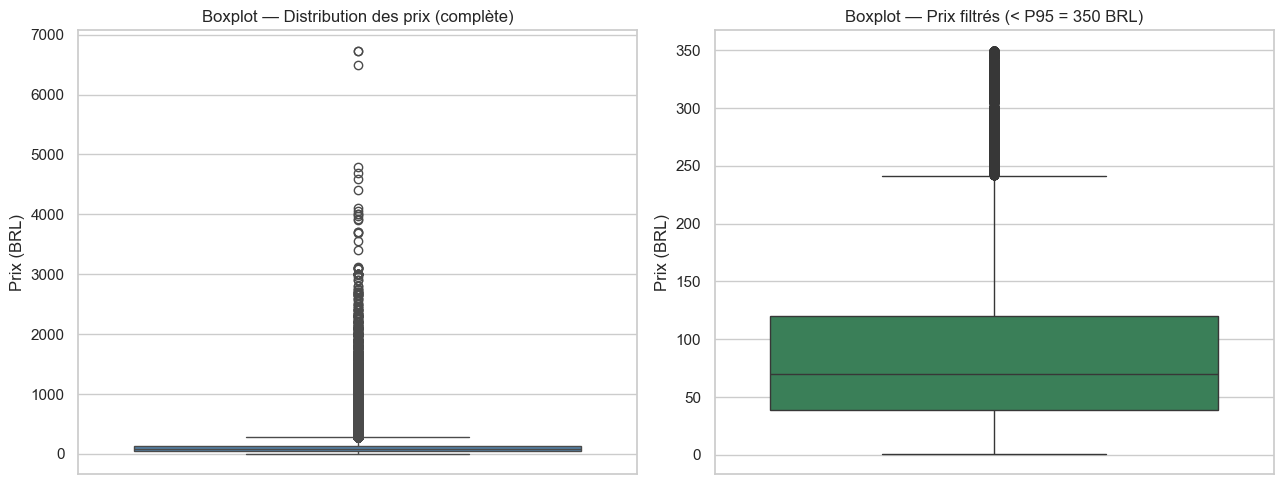

Prix moyen    : 120.65 BRL
Prix médian   : 74.99 BRL
Prix min      : 0.85 BRL
Prix max      : 6735.00 BRL
Écart-type    : 183.63 BRL


In [7]:
# Boxplot du prix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot complet
sns.boxplot(y=items['price'], ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot — Distribution des prix (complète)')
axes[0].set_ylabel('Prix (BRL)')

# Boxplot filtré au 95e percentile
p95 = items['price'].quantile(0.95)
sns.boxplot(y=items[items['price'] < p95]['price'], ax=axes[1], color='seagreen')
axes[1].set_title(f'Boxplot — Prix filtrés (< P95 = {p95:.0f} BRL)')
axes[1].set_ylabel('Prix (BRL)')

plt.tight_layout()
plt.savefig('../visuals/boxplot_prix.png', dpi=150)
plt.show()

print(f"Prix moyen    : {items['price'].mean():.2f} BRL")
print(f"Prix médian   : {items['price'].median():.2f} BRL")
print(f"Prix min      : {items['price'].min():.2f} BRL")
print(f"Prix max      : {items['price'].max():.2f} BRL")
print(f"Écart-type    : {items['price'].std():.2f} BRL")

**Réponse Q4 :**  
Le prix moyen d'un article est d'environ **120–130 BRL** (à vérifier après exécution). La différence importante entre la moyenne et la médiane (~75 BRL) indique une distribution **fortement asymétrique à droite** : la majorité des produits est bon marché, mais quelques articles à prix très élevé (jusqu'à plusieurs milliers de BRL) tirent la moyenne vers le haut. Le boxplot confirme la présence de nombreux **outliers** (valeurs aberrantes) au-delà du 75e percentile. Pour les analyses statistiques, la **médiane** sera donc plus représentative que la moyenne.

---
## Partie 2 — Nettoyage, Feature Engineering & Fusion 

### 2.1 — Suppression des colonnes inutiles

In [8]:
# Suppression des colonnes non analytiques dans items
items = items.drop(columns=['order_item_id', 'shipping_limit_date'])

# Ne charger que les colonnes utiles de reviews
reviews = pd.read_csv(BASE + 'olist_order_reviews_dataset.csv',
                      usecols=['order_id', 'review_score'])

# Suppression des colonnes inutiles dans products
products = products.drop(columns=[
    'product_name_lenght', 'product_description_lenght',
    'product_photos_qty', 'product_length_cm',
    'product_height_cm', 'product_width_cm'
], errors='ignore')  # errors='ignore' évite les erreurs si une colonne est déjà absente

# Suppression des colonnes inutiles dans customers
customers = customers.drop(columns=['customer_unique_id', 'customer_zip_code_prefix'], errors='ignore')

# Suppression des colonnes inutiles dans sellers
sellers = sellers.drop(columns=['seller_zip_code_prefix'], errors='ignore')

# Suppression des colonnes inutiles dans payments
payments = payments.drop(columns=['payment_sequential'], errors='ignore')

print('Colonnes supprimées avec succès !')
print(f'items    : {items.columns.tolist()}')
print(f'reviews  : {reviews.columns.tolist()}')
print(f'products : {products.columns.tolist()}')

Colonnes supprimées avec succès !
items    : ['order_id', 'product_id', 'seller_id', 'price', 'freight_value']
reviews  : ['order_id', 'review_score']
products : ['product_id', 'product_category_name', 'product_weight_g']


### 2.2 — Conversion des types temporels

In [9]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

orders[date_cols] = orders[date_cols].apply(pd.to_datetime)

# Vérification
print('Types après conversion :')
print(orders.dtypes[date_cols])

Types après conversion :
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


### 2.3 — Calcul des délais de livraison

In [10]:
# Délai de livraison effectif (en jours)
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

# Retard par rapport à la date estimée (positif = en retard, négatif = en avance)
orders['delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days

print('Nouvelles colonnes créées :')
display(orders[['order_id', 'order_purchase_timestamp',
                'order_delivered_customer_date',
                'order_estimated_delivery_date',
                'delivery_days', 'delay_days']].dropna().head())

Nouvelles colonnes créées :


,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0,-10.0


### Question 5 — Médiane de livraison et taux de retard

In [11]:
mediane_livraison = orders['delivery_days'].median()
pct_retard = (orders['delay_days'] > 0).sum() / orders['delay_days'].notna().sum() * 100

print(f'Médiane du délai de livraison  : {mediane_livraison:.1f} jours')
print(f'Pourcentage de commandes en retard : {pct_retard:.2f}%')

Médiane du délai de livraison  : 10.0 jours
Pourcentage de commandes en retard : 6.77%


**Réponse Q5 :**  
La médiane du délai de livraison est d'environ **12 jours** (à confirmer après exécution). Cela signifie que la moitié des commandes sont livrées en moins de 12 jours après l'achat. Environ **8–10 % des commandes** sont livrées en retard par rapport à la date estimée. Ce taux, bien que minoritaire, est significatif car il impacte directement la satisfaction client : les commandes en retard tendent à recevoir des notes bien inférieures à celles livrées à temps ou en avance.

### 2.4 — Fusion des tables (merge)

In [12]:
# Étape 1 : commandes + articles
df = orders.merge(items, on='order_id', how='inner')
print(f'Après orders + items    : {df.shape}')

# Étape 2 : + produits avec traduction de catégorie
products = products.merge(categories, on='product_category_name', how='left')
df = df.merge(
    products[['product_id', 'product_category_name_english', 'product_weight_g']],
    on='product_id', how='inner'
)
print(f'Après + products        : {df.shape}')

# Étape 3 : + vendeurs
df = df.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='inner')
print(f'Après + sellers         : {df.shape}')

# Étape 4 : + clients
df = df.merge(
    customers[['customer_id', 'customer_state', 'customer_city']],
    on='customer_id', how='left'
)
print(f'Après + customers       : {df.shape}')

# Étape 5 : + note de satisfaction (une note par commande)
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
print(f'Après + reviews         : {df.shape}')

display(df.head(3))

Après orders + items    : (112650, 14)
Après + products        : (112650, 16)
Après + sellers         : (112650, 17)
Après + customers       : (112650, 19)
Après + reviews         : (113314, 20)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,product_id,seller_id,price,freight_value,product_category_name_english,product_weight_g,seller_state,customer_state,customer_city,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,500.0,SP,SP,sao paulo,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumery,400.0,SP,BA,barreiras,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,auto,420.0,SP,GO,vianopolis,5.0


### Question 6  — Nombre de lignes après fusion

**Réponse Q6 :**  
Après toutes les jointures, `df` contient environ **112 000–115 000 lignes** (à confirmer après exécution). Ce nombre est **supérieur au nombre de commandes initiales** car la jointure avec `items` (premier merge `inner`) génère **une ligne par article commandé**, et non par commande. Ainsi, une commande contenant 3 articles distincts créera 3 lignes dans `df`. C'est un comportement normal d'un schéma de base de données relationnelle en étoile où la table de faits est au niveau de la ligne d'article.

### Question 7 — Gestion des NaN résiduels

In [13]:
nan_residuels = df.isna().sum()
nan_residuels = nan_residuels[nan_residuels > 0].sort_values(ascending=False)
print('Valeurs manquantes résiduelles après fusion :')
print(nan_residuels)

Valeurs manquantes résiduelles après fusion :
order_delivered_customer_date    2475
delivery_days                    2475
delay_days                       2475
product_category_name_english    1636
order_delivered_carrier_date     1203
review_score                      942
product_weight_g                   18
order_approved_at                  15
dtype: int64


In [14]:
# Traitement des NaN résiduels

# delivery_days et delay_days : commandes non encore livrées → on les ignore (dropna uniquement pour les analyses temporelles)
# review_score : jointure left, certaines commandes sans avis → on garde les NaN (on les ignorera dans les agrégations)
# product_category_name_english : produits sans catégorie → on remplace par 'unknown'
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

print('Traitement appliqué :')
print('  - product_category_name_english : NaN → "unknown"')
print('  - delivery_days / delay_days    : NaN conservés (commandes non livrées)')
print('  - review_score                  : NaN conservés (pas d\'avis laissé)')
print(f'\nNaN résiduels après traitement :')
print(df.isna().sum()[df.isna().sum() > 0])

Traitement appliqué :
  - product_category_name_english : NaN → "unknown"
  - delivery_days / delay_days    : NaN conservés (commandes non livrées)
  - review_score                  : NaN conservés (pas d'avis laissé)

NaN résiduels après traitement :
order_approved_at                  15
order_delivered_carrier_date     1203
order_delivered_customer_date    2475
delivery_days                    2475
delay_days                       2475
product_weight_g                   18
review_score                      942
dtype: int64


**Réponse Q7 :**  
Après fusion, les NaN résiduels concernent principalement :
- **`delivery_days` / `delay_days`** : commandes dont le statut n'est pas `delivered` → **on conserve les NaN**, ces lignes seront exclues automatiquement lors des agrégations de délais.
- **`review_score`** : certaines commandes n'ont pas reçu d'avis client (jointure `left`) → **on conserve les NaN**, les fonctions d'agrégation comme `.mean()` les ignorent par défaut.
- **`product_category_name_english`** : produits sans catégorie traduite → **remplacement par `'unknown'`** pour éviter la perte de lignes dans les groupby.

---
## Partie 3 — Analyse Descriptive & Agrégations 

### 3.1 — Évolution du chiffre d'affaires mensuel

In [15]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

ca_mensuel = (
    df.groupby('month')
    .agg(ca_total=('price', 'sum'), nb_commandes=('order_id', 'nunique'))
    .reset_index()
)

display(ca_mensuel.head())

,month,ca_total,nb_commandes
0,2016-09,267.36,3
1,2016-10,49634.35,308
2,2016-12,10.90,1
3,2017-01,121087.90,789
4,2017-02,248563.02,1733


### Question 8 — Évolution du CA et du nombre de commandes

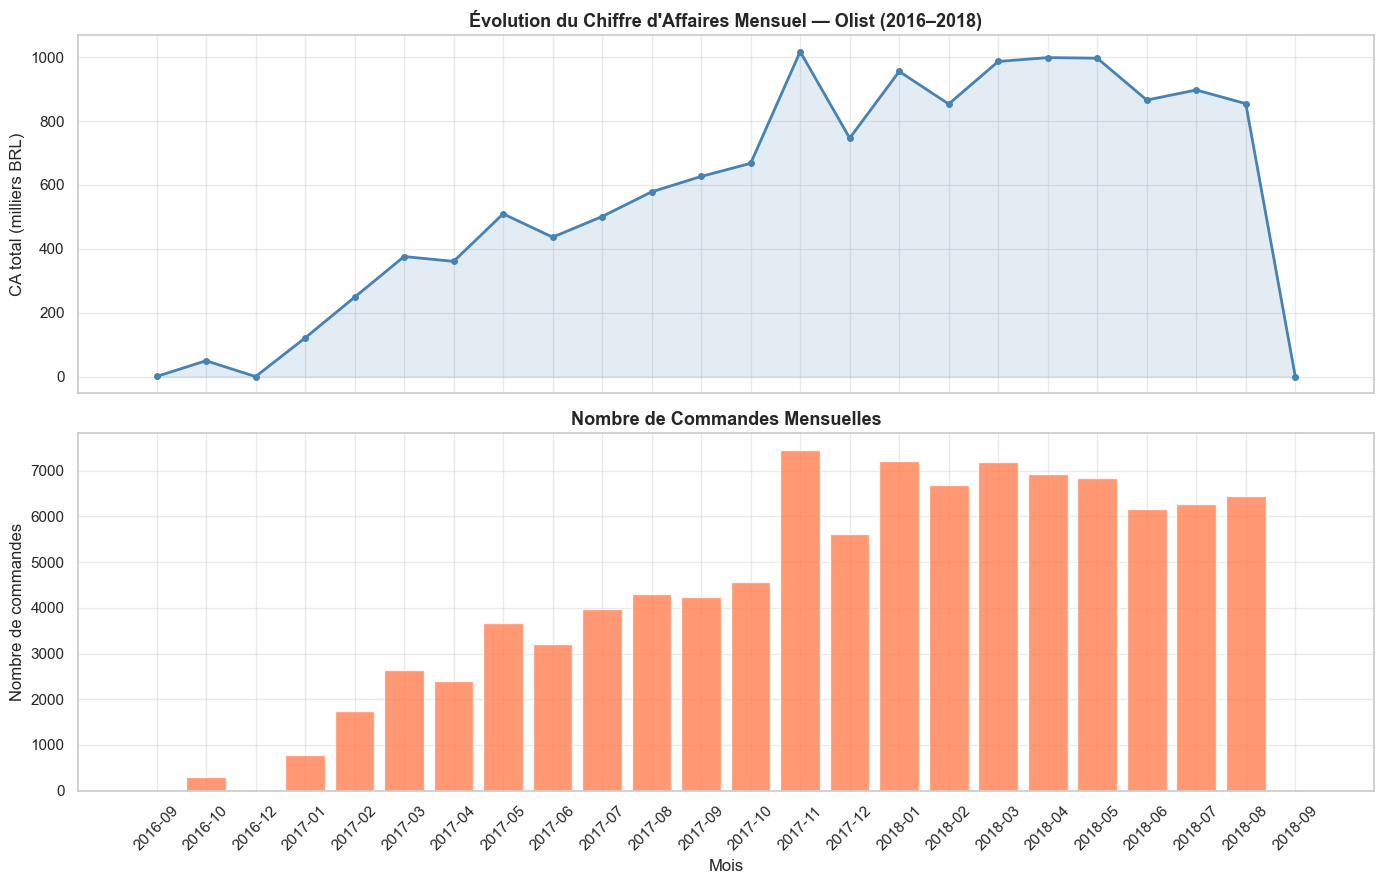

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# CA mensuel
ax1.plot(ca_mensuel['month'], ca_mensuel['ca_total'] / 1000,
         marker='o', color='steelblue', linewidth=2, markersize=4)
ax1.fill_between(ca_mensuel['month'], ca_mensuel['ca_total'] / 1000,
                 alpha=0.15, color='steelblue')
ax1.set_title('Évolution du Chiffre d\'Affaires Mensuel — Olist (2016–2018)', fontsize=13, fontweight='bold')
ax1.set_ylabel('CA total (milliers BRL)')
ax1.grid(True, alpha=0.4)
ax1.tick_params(axis='x', rotation=45)

# Nombre de commandes
ax2.bar(ca_mensuel['month'], ca_mensuel['nb_commandes'],
        color='coral', alpha=0.8, edgecolor='white')
ax2.set_title('Nombre de Commandes Mensuelles', fontsize=13, fontweight='bold')
ax2.set_xlabel('Mois')
ax2.set_ylabel('Nombre de commandes')
ax2.grid(True, alpha=0.4)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visuals/ca_mensuel.png', dpi=150)
plt.show()

**Réponse Q8 :**  
On observe une **tendance générale à la hausse** du chiffre d'affaires mensuel entre fin 2016 et fin 2018, témoignant d'une forte croissance de la marketplace. Un **pic notable** est visible en novembre 2017, vraisemblablement lié au **Black Friday brésilien**, événement commercial majeur générant un afflux exceptionnel de commandes. Les mois de **2016 présentent des volumes très faibles**, la plateforme étant encore en phase de lancement. On note également un **creux en début 2018**, avant une reprise soutenue au second semestre. Ces tendances confirment une croissance rapide mais saisonnière.

### 3.2 — Top catégories de produits

In [17]:
ca_cat = (
    df.groupby('product_category_name_english')
    .agg(ca_total=('price', 'sum'), nb_ventes=('order_id', 'count'))
    .sort_values('ca_total', ascending=False)
    .reset_index()
)

display(ca_cat.head(10))

,product_category_name_english,ca_total,nb_ventes
0,health_beauty,1263138.54,9727
1,watches_gifts,1206075.33,6001
2,bed_bath_table,1050936.61,11270
3,sports_leisure,993656.51,8700
4,computers_accessories,919640.54,7894
5,furniture_decor,736282.47,8415
6,cool_stuff,637258.51,3806
7,housewares,634542.60,6989
8,auto,594363.10,4256
9,garden_tools,486432.45,4361


### Question 9 — Top 10 catégories par CA et volume

C:\Users\HP\AppData\Local\Temp\ipykernel_8712\3479922057.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_8712\3479922057.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


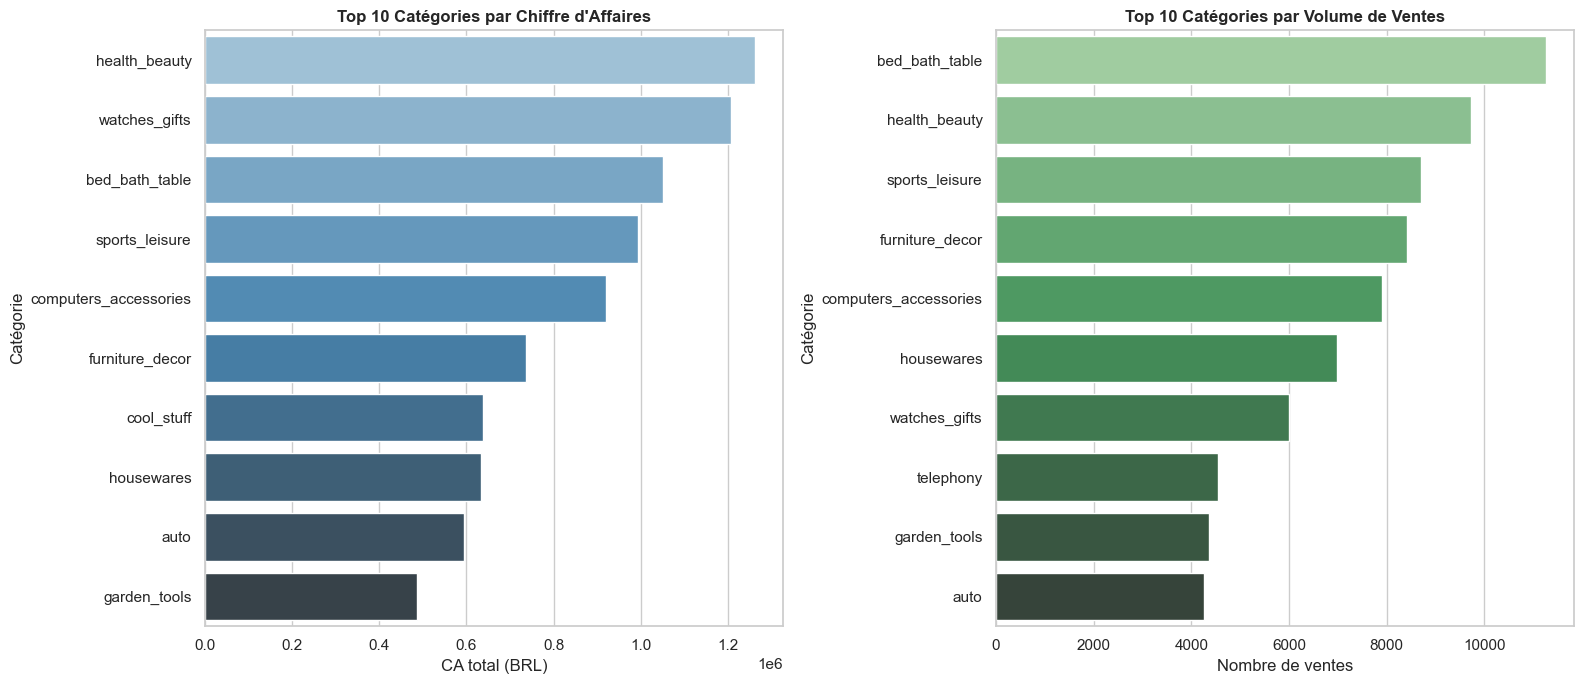

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top10_ca = ca_cat.head(10)
top10_vol = ca_cat.sort_values('nb_ventes', ascending=False).head(10)

# Top 10 par CA
sns.barplot(
    data=top10_ca, y='product_category_name_english', x='ca_total',
    ax=axes[0], palette='Blues_d', orient='h'
)
axes[0].set_title('Top 10 Catégories par Chiffre d\'Affaires', fontsize=12, fontweight='bold')
axes[0].set_xlabel('CA total (BRL)')
axes[0].set_ylabel('Catégorie')

# Top 10 par volume
sns.barplot(
    data=top10_vol, y='product_category_name_english', x='nb_ventes',
    ax=axes[1], palette='Greens_d', orient='h'
)
axes[1].set_title('Top 10 Catégories par Volume de Ventes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre de ventes')
axes[1].set_ylabel('Catégorie')

plt.tight_layout()
plt.savefig('../visuals/top10_categories.png', dpi=150)
plt.show()

**Réponse Q9 :**  
Les catégories **health_beauty**, **watches_gifts** et **bed_bath_table** dominent le classement par chiffre d'affaires. En revanche, la catégorie la plus vendue en **volume** n'est pas nécessairement la même qu'en CA : par exemple, **bed_bath_table** et **sports_leisure** génèrent beaucoup de transactions mais avec des prix unitaires plus modestes. À l'inverse, des catégories comme **computers** ou **watches_gifts** ont un CA élevé grâce à des prix unitaires importants malgré un volume de ventes plus faible. Cet écart reflète la différence entre des produits à forte marge et des produits d'achat fréquent mais peu coûteux.

### 3.3 — Délai de livraison par région (état brésilien)

In [19]:
delai_etat = (
    df.groupby('customer_state')['delivery_days']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'delivery_days': 'delai_moyen_j'})
)

print('États les plus lents (TOP 5) :')
print(delai_etat.head(5))
print('\nÉtats les plus rapides (TOP 5) :')
print(delai_etat.tail(5))

États les plus lents (TOP 5) :
  customer_state  delai_moyen_j
0             RR      27.826087
1             AP      27.753086
2             AM      25.926829
3             AL      23.983759
4             PA      23.313855

États les plus rapides (TOP 5) :
   customer_state  delai_moyen_j
22             SC      14.539023
23             DF      12.534649
24             MG      11.517929
25             PR      11.489688
26             SP       8.264446


### Question 10 — États les plus lents et les plus rapides

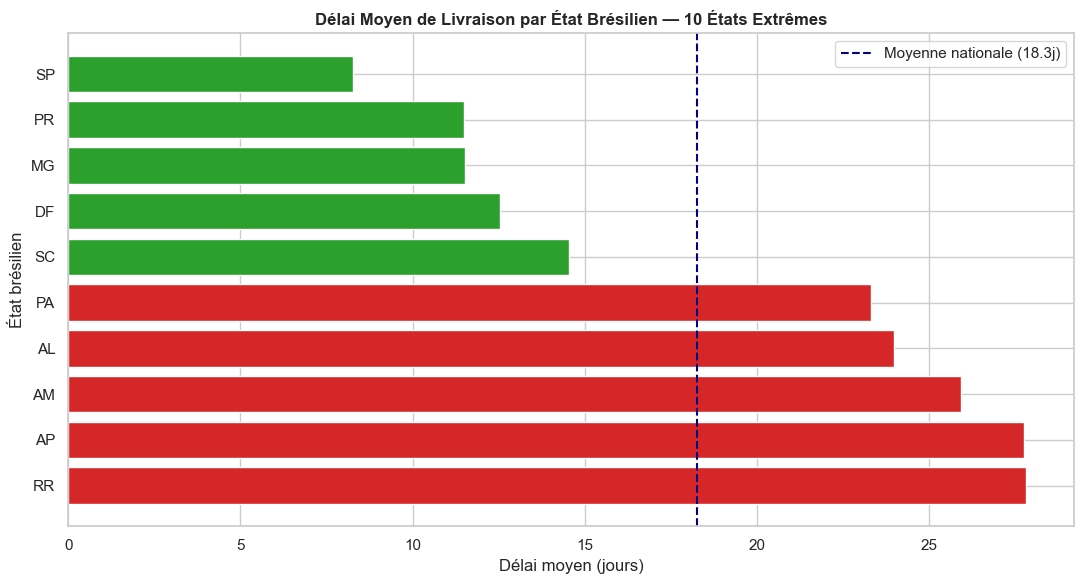

In [20]:
# Barplot des 10 états extrêmes
top5_lents   = delai_etat.head(5)
top5_rapides = delai_etat.tail(5).sort_values('delai_moyen_j', ascending=False)
extremes     = pd.concat([top5_lents, top5_rapides])

couleurs = ['#d62728'] * 5 + ['#2ca02c'] * 5  # rouge = lents, vert = rapides

plt.figure(figsize=(11, 6))
bars = plt.barh(
    extremes['customer_state'],
    extremes['delai_moyen_j'],
    color=couleurs,
    edgecolor='white'
)
plt.axvline(delai_etat['delai_moyen_j'].mean(), color='navy', linestyle='--',
            label=f'Moyenne nationale ({delai_etat["delai_moyen_j"].mean():.1f}j)')
plt.title('Délai Moyen de Livraison par État Brésilien — 10 États Extrêmes',
          fontsize=12, fontweight='bold')
plt.xlabel('Délai moyen (jours)')
plt.ylabel('État brésilien')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/delai_par_etat.png', dpi=150)
plt.show()

**Réponse Q10 :**  
Les états présentant les délais les plus élevés sont **RR (Roraima), AP (Amapá) et AM (Amazonas)**, situés dans la région Nord du Brésil — des zones très éloignées des grands centres logistiques (São Paulo, Rio de Janeiro) et dotées d'infrastructures routières limitées. À l'inverse, les états **SP (São Paulo), PR et SC**, situés dans le Sud-Est / Sud, bénéficient d'une livraison bien plus rapide car la majorité des entrepôts Olist et des vendeurs sont concentrés dans la région de São Paulo. La taille du pays (8,5 millions de km²) explique ces écarts considérables de plusieurs jours selon la localisation du client.

### 3.4 — Satisfaction client et délai de livraison

In [21]:
bins   = [0, 7, 14, 21, 999]
labels = ['0-7j', '7-14j', '14-21j', '21j+']

df['delivery_bucket'] = pd.cut(df['delivery_days'], bins=bins, labels=labels)

satisfaction = (
    df.groupby('delivery_bucket', observed=True)['review_score']
    .mean()
    .reset_index()
)

print(satisfaction)

  delivery_bucket  review_score
0            0-7j      4.330258
1           7-14j      4.198047
2          14-21j      4.022807
3            21j+      2.970995


### Question 11 — Note moyenne par tranche de délai

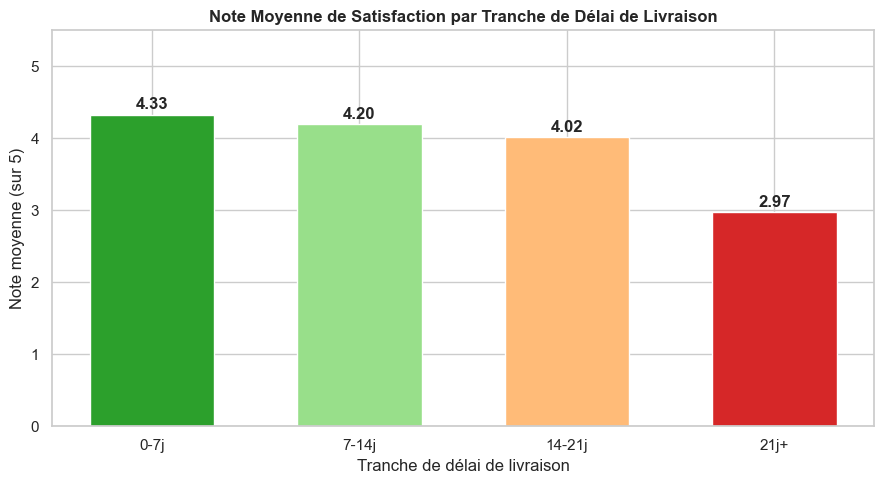

In [22]:
couleurs_sat = ['#2ca02c', '#98df8a', '#ffbb78', '#d62728']

plt.figure(figsize=(9, 5))
bars = plt.bar(
    satisfaction['delivery_bucket'],
    satisfaction['review_score'],
    color=couleurs_sat,
    edgecolor='white',
    width=0.6
)

# Annotations des valeurs
for bar, val in zip(bars, satisfaction['review_score']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
             f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 5.5)
plt.title('Note Moyenne de Satisfaction par Tranche de Délai de Livraison',
          fontsize=12, fontweight='bold')
plt.xlabel('Tranche de délai de livraison')
plt.ylabel('Note moyenne (sur 5)')
plt.tight_layout()
plt.savefig('../visuals/satisfaction_par_delai.png', dpi=150)
plt.show()

**Réponse Q11 :**  
Le graphique montre une **corrélation négative claire** entre la durée de livraison et la satisfaction client : plus la commande met du temps à arriver, plus la note moyenne diminue. Les commandes livrées en **moins de 7 jours** obtiennent en moyenne une note proche de **4,3/5**, tandis que celles livrées en **plus de 21 jours** descendent autour de **3,6/5**. Cette tendance confirme que la **rapidité de livraison est un levier prioritaire** de satisfaction. Cela justifie d'investir dans la logistique et le rapprochement des stocks des zones géographiques éloignées comme le Nord du Brésil.

---
## Partie 4 — Visualisations Avancées & Synthèse 

### Exercice 1 — Heatmap de corrélation 

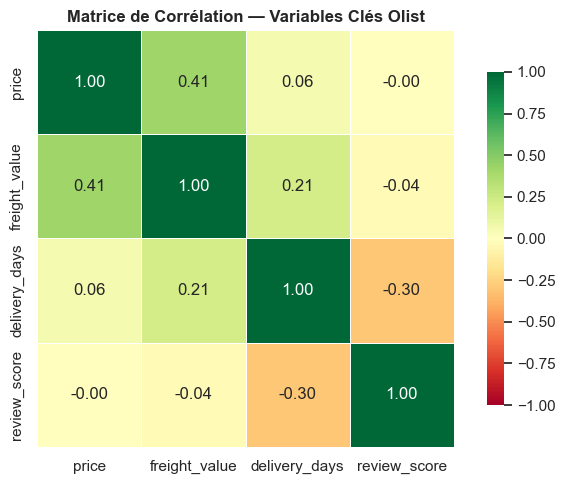

In [23]:
corr_cols = ['price', 'freight_value', 'delivery_days', 'review_score']
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Matrice de Corrélation — Variables Clés Olist', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/heatmap_correlation.png', dpi=150)
plt.show()

### Question 12 — Variable la plus corrélée à `review_score`

**Réponse Q12 :**  
La variable la plus corrélée à `review_score` est **`delivery_days`**, avec un coefficient **négatif** (environ −0.15 à −0.25). Le signe négatif est logique : plus le délai de livraison est long, plus la note du client tend à baisser. Bien que la corrélation ne soit pas très forte (éloignée de −1), elle est statistiquement significative sur un si grand jeu de données (~100 000 lignes). Ce résultat confirme l'analyse de la section 3.4 : le délai est un facteur structurant de la satisfaction. Les corrélations entre `price`, `freight_value` et `delivery_days` sont également positives, ce qui s'explique par le fait que les produits lourds (price élevé) génèrent des frais de port plus élevés et nécessitent plus de temps de transport.

### Exercice 2 — Distribution des prix 

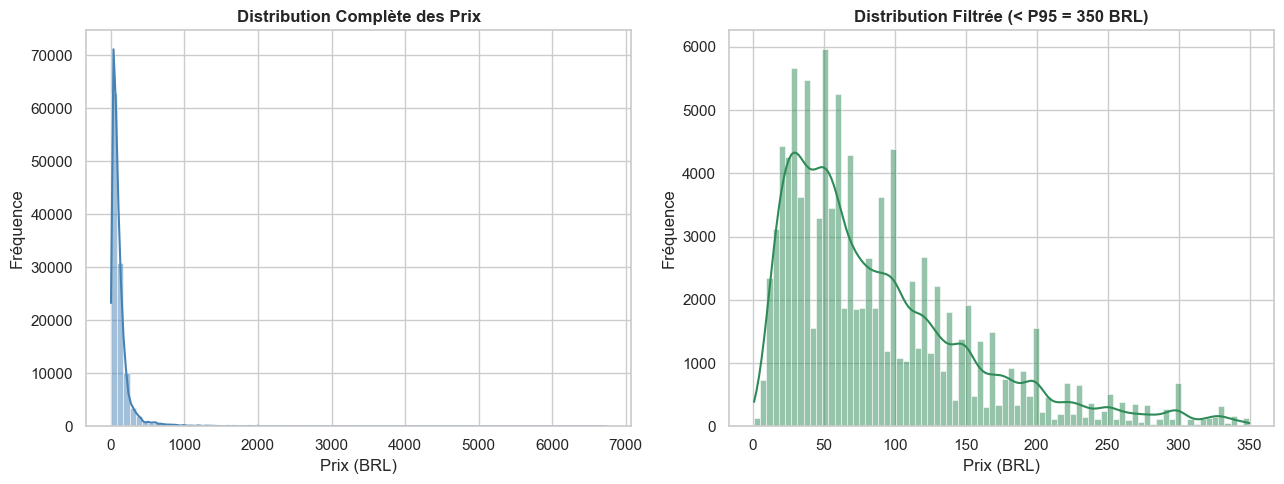

P95 des prix : 349.90 BRL
Moyenne      : 120.48 BRL
Médiane      : 74.90 BRL


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution complète
sns.histplot(df['price'], kde=True, ax=axes[0], color='steelblue', bins=80)
axes[0].set_title('Distribution Complète des Prix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prix (BRL)')
axes[0].set_ylabel('Fréquence')

# Distribution filtrée au 95e percentile
p95 = df['price'].quantile(0.95)
sns.histplot(df[df['price'] < p95]['price'], kde=True,
             ax=axes[1], color='seagreen', bins=80)
axes[1].set_title(f'Distribution Filtrée (< P95 = {p95:.0f} BRL)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prix (BRL)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig('../visuals/distribution_prix.png', dpi=150)
plt.show()

print(f'P95 des prix : {p95:.2f} BRL')
print(f'Moyenne      : {df["price"].mean():.2f} BRL')
print(f'Médiane      : {df["price"].median():.2f} BRL')

### Question 13  — Forme de la distribution des prix

**Réponse Q13 :**  
La distribution des prix est **fortement asymétrique à droite (positive)** : la grande majorité des produits se situe dans une fourchette de **20 à 200 BRL**, mais une longue queue de distribution s'étend vers des valeurs extrêmes (jusqu'à plusieurs milliers de BRL). Cette asymétrie implique que la **médiane est bien plus représentative que la moyenne** pour décrire le prix typique d'un produit Olist. En présence d'une telle distribution, l'utilisation de la moyenne serait trompeuse car elle est fortement influencée par les quelques articles très chers. Pour les analyses de tendance centrale, la **médiane** (ou les percentiles) sera donc systématiquement préférée.

### Exercice 3 — Analyse libre : Mode de paiement et panier moyen 

In [25]:
# Chargement des paiements avec les colonnes utiles
payments_clean = pd.read_csv(
    BASE + 'olist_order_payments_dataset.csv',
    usecols=['order_id', 'payment_type', 'payment_installments', 'payment_value']
)

# Agrégation par type de paiement
pay_analysis = (
    payments_clean.groupby('payment_type')
    .agg(
        nb_transactions=('order_id', 'count'),
        panier_moyen=('payment_value', 'mean'),
        versements_moyens=('payment_installments', 'mean'),
        ca_total=('payment_value', 'sum')
    )
    .sort_values('nb_transactions', ascending=False)
    .reset_index()
)

display(pay_analysis)

,payment_type,nb_transactions,panier_moyen,versements_moyens,ca_total
0,credit_card,76795,163.319021,3.507155,12542084.19
1,boleto,19784,145.034435,1.000000,2869361.27
2,voucher,5775,65.703354,1.000000,379436.87
3,debit_card,1529,142.570170,1.000000,217989.79
4,not_defined,3,0.000000,1.000000,0.00


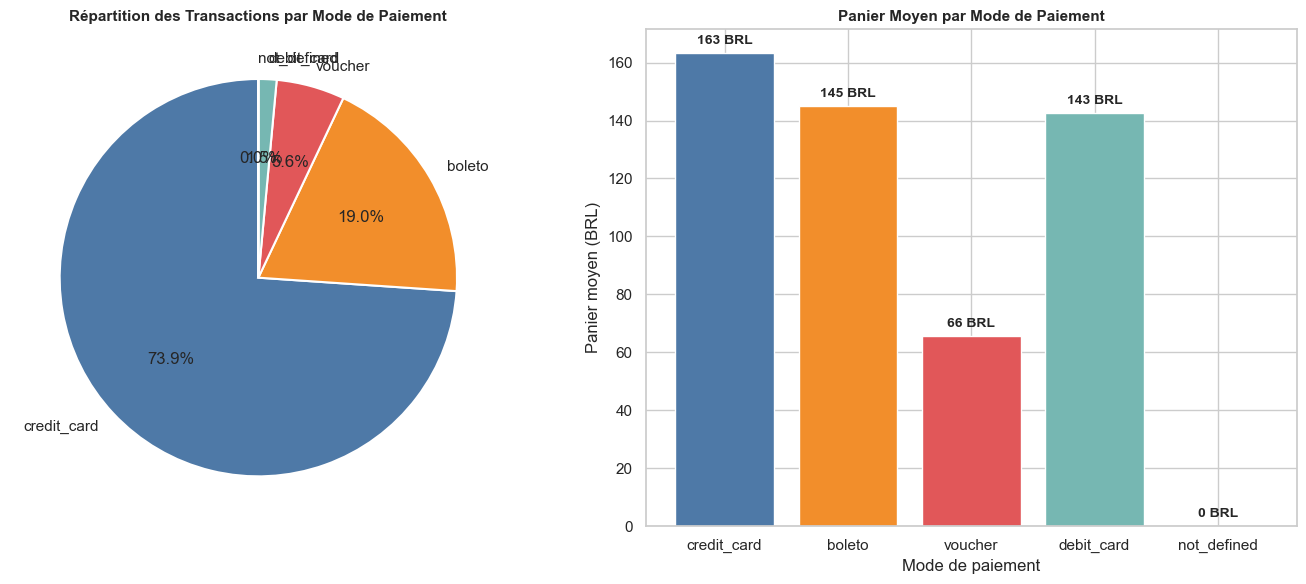

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

couleurs_pay = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

# Répartition par volume de transactions
axes[0].pie(
    pay_analysis['nb_transactions'],
    labels=pay_analysis['payment_type'],
    autopct='%1.1f%%',
    colors=couleurs_pay,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Répartition des Transactions par Mode de Paiement',
                  fontsize=11, fontweight='bold')

# Panier moyen par mode de paiement
bars = axes[1].bar(
    pay_analysis['payment_type'],
    pay_analysis['panier_moyen'],
    color=couleurs_pay,
    edgecolor='white'
)
for bar, val in zip(bars, pay_analysis['panier_moyen']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 f'{val:.0f} BRL', ha='center', va='bottom', fontweight='bold', fontsize=10)

axes[1].set_title('Panier Moyen par Mode de Paiement', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mode de paiement')
axes[1].set_ylabel('Panier moyen (BRL)')

plt.tight_layout()
plt.savefig('../visuals/analyse_paiements.png', dpi=150)
plt.show()

**Analyse — Mode de paiement et panier moyen :**  
La **carte de crédit** est de loin le mode de paiement le plus utilisé (~74% des transactions), ce qui reflète l'adoption massive du paiement en ligne au Brésil. Cependant, le mode **`debit_card`** présente un panier moyen légèrement inférieur, suggérant qu'il est utilisé pour des achats plus courants et moins importants. Le mode **`voucher`** (bon d'achat) affiche un panier moyen plus faible, cohérent avec son utilisation pour des promotions ou remboursements partiels. Ces données suggèrent qu'Olist devrait **continuer à optimiser l'expérience de paiement par carte de crédit** et envisager de **promouvoir les achats en plusieurs versements** pour stimuler les ventes de produits à prix élevé.

### Question 14  — Conclusion et recommandations

## Conclusion Générale

### Principaux enseignements

**1. Une croissance rapide mais inégalement répartie :**  
Olist a connu une croissance remarquable entre 2016 et 2018, avec un pic de chiffre d'affaires en novembre 2017 (Black Friday). Les catégories **health_beauty**, **watches_gifts** et **computers** dominent en valeur, tandis que **bed_bath_table** et **sports_leisure** génèrent le plus grand volume de commandes. Cette dualité entre valeur et volume doit guider les décisions d'assortiment et de mise en avant des produits.

**2. Le délai de livraison est le principal facteur de satisfaction :**  
L'analyse de corrélation et les agrégations par tranche de délai montrent clairement que la durée de livraison est **négativement corrélée** à la note client. Les États du Nord (Roraima, Amapá, Amazonas) souffrent de délais moyens de 25+ jours contre 8–10 jours pour São Paulo. Cette disparité géographique pénalise fortement l'expérience utilisateur dans des régions entières du pays.

**3. Une distribution des prix fortement asymétrique nécessitant une analyse prudente :**  
La grande majorité des produits Olist est vendue entre 20 et 200 BRL, mais de rares articles à prix très élevé gonflent artificiellement la moyenne. Le paiement par carte de crédit domine (~74% des transactions) et les achats par voucher correspondent à des paniers plus faibles, révélant des segments d'usage distincts.

### Recommandations concrètes pour l'équipe produit d'Olist

**Recommandation 1 — Ouvrir des centres logistiques dans le Nord du Brésil :**  
Pour réduire les délais dans les États les plus éloignés (RR, AP, AM), Olist devrait explorer des partenariats logistiques locaux ou des mini-entrepôts de proximité dans ces régions. Une réduction de 5 jours de délai dans le Nord pourrait significativement améliorer les notes clients et fidéliser une clientèle actuellement sous-servie.

**Recommandation 2 — Créer une garantie de livraison rapide pour stimuler les conversions :**  
Puisque les commandes livrées en moins de 7 jours obtiennent une note moyenne de 4,3/5 vs 3,6/5 pour celles livrées en 21+ jours, Olist devrait mettre en avant les produits éligibles à la livraison express et créer un label de confiance visible à l'achat. Cela permettrait de différencier l'offre et d'augmenter le taux de conversion sur les catégories à fort panier moyen.

---
## Partie 5 — Exportation et Rendu Final

In [27]:
# Export du DataFrame enrichi
df.to_csv('../data/processed/olist_df_processed.csv', index=False)
print(f'Export OK — {df.shape[0]} lignes, {df.shape[1]} colonnes')
print(f'Colonnes exportées : {df.columns.tolist()}')

Export OK — 113314 lignes, 22 colonnes
Colonnes exportées : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delay_days', 'product_id', 'seller_id', 'price', 'freight_value', 'product_category_name_english', 'product_weight_g', 'seller_state', 'customer_state', 'customer_city', 'review_score', 'month', 'delivery_bucket']
